#### Import Libraries

In [1]:
import os
import logging  
import pandas as pd 
import numpy as np 
import talib 
import yfinance as yf
import matplotlib.pyplot as plt 
%matplotlib inline 
import datetime 
from sklearn import linear_model 
from sklearn.metrics import accuracy_score, log_loss, precision_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split 

import warnings 
warnings.filterwarnings('ignore') 

logging.basicConfig(filename='workflow.log', level=logging.INFO,
                    format='%(message)s') 

#### Extracting tickers and Downloading data

In [2]:
logging.info('Extracting Tickers Table-1')
tickers = pd.read_html('https://en.wikipedia.org/wiki/List_of_public_corporations_by_market_capitalization')[0] 

In [3]:
tickers 

Company Country When first passed                                     \
        Company Country       $1 trillion       $2 trillion      $3 trillion   
0        Nvidia     NaN       30 May 2023  23 February 2024      5 June 2024   
1     Microsoft     NaN     25 April 2019      22 June 2021  24 January 2024   
2         Apple     NaN     2 August 2018    19 August 2020   3 January 2022   
3  Saudi Aramco     NaN  11 December 2019  12 December 2019                —   
4      Alphabet     NaN   16 January 2020   8 November 2021                —   
5        Amazon     NaN  4 September 2018                 —                —   
6          Meta     NaN      28 June 2021                 —                —   
7         Tesla     NaN   25 October 2021                 —                —   

  Record value date Record value (in billions USD)                         \
  Record value date                        Nominal Inflation- adjusted[5]   
0      20 June 2024                           3450                   3450   
1      17 June 2024                           3332                   3332   
2      12 June 2024                           3331                   3331   
3       10 May 2022                           2463                   2564   
4     26 April 2024                           2150                   2150   
5     11 April 2024                           1970                   1970   
6   2 February 2024                           1220                   1220   
7   1 November 2021                           1210                   1361   

              Notes  
              Notes  
0      [6][7][8][9]  
1  [10][11][12][13]  
2  [14][15][16][17]  
3      [18][19][20]  
4      [21][22][23]  
5      [24][25][26]  
6  [note 1][27][28]  
7          [29][30]

We are interested only in the name of the companies

In [4]:
tickers = tickers['Company']

In [5]:
tickers

,Company
0,Nvidia
1,Microsoft
2,Apple
3,Saudi Aramco
4,Alphabet
5,Amazon
6,Meta
7,Tesla


Now, we want the list of symbols of these tickers

In [6]:
logging.info('Extarcting Tickers Table-2')
ticker_ext = pd.read_html('https://en.wikipedia.org/wiki/Russell_1000_Index')[2] 

In [7]:
ticker_ext.head() 

,Company,Ticker,GICS Sector,GICS Sub-Industry
0,10x Genomics,TXG,Health Care,NaN
1,3M,MMM,Industrials,Industrial Conglomerates
2,Abbott,ABT,Health Care,Health Care Equipment
3,AbbVie,ABBV,Health Care,Pharmaceuticals
4,Acadia Healthcare,ACHC,Health Care,Health Care Facilities


In [8]:
ticker_ext = ticker_ext[['Company','Ticker']]  

In [9]:
ticker_ext

,Company,Ticker
0,10x Genomics,TXG
1,3M,MMM
2,Abbott,ABT
3,AbbVie,ABBV
4,Acadia Healthcare,ACHC
...,...,...
998,Zions Bancorporation,ZION
999,Zoetis,ZTS
1000,Zoom,ZM
1001,ZoomInfo,ZI


In [10]:
logging.info('Merging Table-1 and Table-2')
df = (pd.merge(tickers, ticker_ext, on='Company', how='left')).dropna()  

In [11]:
df = df.set_index('Company') 

In [12]:
df 

,Ticker
Company,
Nvidia,NVDA
Microsoft,MSFT
Apple,AAPL
Amazon,AMZN
Meta,META
Tesla,TSLA


#### Developing and Evaluating the strategy only for one asset

In [13]:
def data_extraction(tick):

    logging.info(f'Started FN-1')

    data = yf.download(tick,start='2011-01-01')
    data1 = data.copy()

    asset_high = data1['High'] 
    asset_low = data1['Low'] 
    asset_open = data1['Open'] 
    asset_close = data1['Close'] 
    asset_volume = data1['Volume'] 

    logging.info(f'Exited FN-1')

    return asset_high, asset_low, asset_open, asset_close, asset_volume

### 1. Oscillators and Trend Following Indicators

#### 1.1 MACD andMACD Histogram

In [14]:
def macd_machd(asset_close):

    logging.info(f'Started FN-2')

    macd, macdsignal, macdhist = talib.MACD(asset_close, fastperiod=12, slowperiod=26, signalperiod=9) 
    dict = {'MACD':macd,'MSIG':macdsignal} 
    macdata = []
    macdata = pd.DataFrame(data=dict) 
    macdata.dropna(inplace=True) 
    macdata['MACD_Signal1'] = macdata.apply(lambda x: 1 if x['MACD']>x['MSIG'] else 0, axis=1) 
    n_days = len(macdata['MACD']) 
    Signal = macdata['MACD_Signal1'] 
    psy = [] 
    for i in range(0, n_days):
        if Signal[i]==1:
            psy.append(1) 

        elif Signal[i]==0:
            psy.append(0) 
    macdata['MACD_Signal'] = psy 
    del macdata['MACD_Signal1']    

    dict = {'MHIST':macdhist,'PrevMHIST':macdhist.shift(1)} 
    machdata = [] 
    machdata = pd.DataFrame(data=dict) 
    machdata.dropna(inplace=True) 
    machdata['MHIST_Signal1'] = machdata.apply(lambda x: 1 if x['MHIST']>x['PrevMHIST'] else 0, axis=1) 
    n_days = len(machdata['MHIST']) 
    Signal = machdata['MHIST_Signal1'] 
    psy = [] 
    for i in range (0,n_days):
        if Signal[i]==1:
            psy.append(1)
        elif Signal[i]==0:
            psy.append(0) 

    machdata['MHIST_Signal'] = psy 
    del machdata['MHIST_Signal1']  

    logging.info(f'Exited FN-2')

    return macdata, machdata   

#### 1.2 Average Directional Index (ADX) 

In [15]:
def adx_index(asset_high,asset_low,asset_close):
    
    logging.info(f'Started FN-3')

    adx = talib.ADX(asset_high, asset_low, asset_close, timeperiod=14) 
    adx.isnull().sum()
    dict = {'Close':asset_close,'ADX':adx} 
    adxdata = [] 
    adxdata = pd.DataFrame(data=dict)
    adxdata.dropna(inplace=True) 
    adxdata['adx1'] = adxdata.apply(lambda x: 1 if x['ADX']>25 else 0, axis=1)
    adxdata['adx2'] = adxdata.apply(lambda x: -1 if x['ADX']<20 else 0, axis=1)
    adxdata['Signw'] = adxdata.apply(lambda x: x['adx1']+x['adx2'], axis=1)
    n_days = len(adxdata['ADX']) 
    Signal = adxdata['Signw'] 
    psy = [] 
    for i in range(0,n_days):
        if Signal[i]==1:
            psy.append(1)
        elif Signal[i]==-1 or Signal[i]==0:
            psy.append(0) 

    adxdata['Trend'] = psy 
    del adxdata['Signw'] 
    del adxdata['adx1'] 
    del adxdata['adx2'] 

    logging.info(f'Exited FN-3')      

    return adxdata  

#### 1.3 Relative Strength Index (RSI) 

In [16]:
def rsi_index(asset_close):
    
    logging.info(f'Started FN-4')
    
    rsi = talib.RSI(asset_close, timeperiod=14) 
    dict = {'Close':asset_close,'RSI':rsi} 
    rsidata = []
    rsidata = pd.DataFrame(data=dict) 
    rsidata.dropna(inplace=True) 
    rsidata['rsi1'] = rsidata.apply(lambda x: 1 if x['RSI']<30 else 0, axis=1) 
    rsidata['rsi2'] = rsidata.apply(lambda x: -1 if x['RSI']>70 else 0, axis=1) 
    rsidata['Sign1'] = rsidata.apply(lambda x: x['rsi1']+x['rsi2'], axis=1) 
    n_days = len(rsidata['RSI']) 
    Signal = rsidata['Sign1']
    psy = []

    for i in range(0,n_days):
        if Signal[i]==1:
            psy.append(1) 
        elif Signal[i]==-1 or Signal[i]==0:
            psy.append(0) 

    rsidata['Psycology'] = psy 
    del rsidata['Sign1'] 
    del rsidata['rsi1'] 
    del rsidata['rsi2'] 

    logging.info(f'Exited FN-4')

    return rsidata 

### 2. Volatility Indicators

#### 2.1 Bollinger Bands

In [17]:
def bb_bands(asset_close):
    
    logging.info(f'Started FN-5')
    
    upper, middle, lower = talib.BBANDS(asset_close, timeperiod=26)
    dict = {'Close':asset_close,'Middle':middle,'Upper':upper,'Lower':lower}
    bbdata = []
    bbdata = pd.DataFrame(data=dict) 
    bbdata.dropna(inplace=True) 

    #Generate long and short Signals
    n_days = len(bbdata['Middle']) 
    cash = 1
    stock = 0
    position = []
    spread = asset_close 
    ma = middle 
    upper_band = upper 
    lower_band = lower 

    for i in range(0,n_days):

        #Long if spread<lower band & if not bought yet
        if spread[i]<lower_band[i] and cash==1:
            signal = 1
            cash = 0
            stock = 0
            position.append(signal) 

        # Take profit if apread>moving average and if already bought
        elif spread[i]>ma[i] and stock==1:
            signal = 3
            cash = 1
            stock = 0
            position.append(signal) 

        # Short if spread>upper band and no current position
        elif spread[i]>upper_band[i] and cash==1:
            signal = -1
            cash =0 
            stock = -1 
            position.append(signal) 

        # Take profit if spread<moving average & if already short
        elif spread[i] < ma[i] and stock==-1:
            signal = 3
            cash = 1
            stock = 0
            position.append(signal) 
        else:
            signal=0
            position.append(signal) 

    bbdata['Position1'] = position
    bbdata['Position1'] = bbdata['Position1'].replace(to_replace=0, method='ffill') 
    bbdata['Position1'] = bbdata['Position1'].replace(3,0) 
    bbdata['Position'] = bbdata['Position1'] 
    del bbdata['Position1']

    t_days = len(bbdata['Middle']) 
    Signal = bbdata['Position'] 
    pos = []

    for i in range(0,t_days):
        if Signal[i]==0 or Signal[i]==-1: 
            pos.append(0)
        elif Signal[i]==1:
            pos.append(1)  

    bbdata['Strategy'] = pos 

    logging.info(f'Exited FN-5')
    
    return bbdata 

#### 2.2 Force Index 

In [18]:
def force_index(asset_volume,asset_close):
    
    logging.info(f'Started FN-6')
    
    # Force Index Function
    def ForceIndex(Volume, Close):
        dict = {'Volume':Volume,'Close':Close} 
        df = pd.DataFrame(data=dict) 
        df.dropna(inplace=True) 
        FI = df['Volume']*(df['Close']-df['Close'].shift(1)) 
        return FI 

    # Compute Force Index 
    fi = ForceIndex(asset_volume,asset_close) 
    efi = talib.EMA(fi, timeperiod=13)
    dict = {'Close':asset_close,'EFI':efi} 
    efidata = []
    efidata = pd.DataFrame(data=dict) 
    efidata.dropna(inplace=True) 
    efidata['efi_sign'] = efidata.apply(lambda x: 1 if x['EFI']>0 else -1, axis=1) 
    n_days = len(efidata['EFI']) 
    Signal = efidata['efi_sign'] 
    psy = []


    for i in range(0,n_days):
        if Signal[i]==1:
            psy.append(1) 
        elif Signal[i]==-1:
            psy.append(0) 

    efidata['Psycology'] = psy 
    del efidata['efi_sign'] 

    logging.info(f'Exited FN-6')
    
    return efidata 

### 3. Classify next days stock move

In [19]:
def next_day_move(asset_close):

    logging.info(f'Started FN-7')
    
    asset_move = asset_close.shift(-1) 
    dict = {'Close':asset_close,'Move':asset_move} 
    sdmdata = []
    sdmdata = pd.DataFrame(data=dict) 
    sdmdata.dropna(inplace=True) 
    sdmdata['sign'] = sdmdata.apply(lambda x: 1 if np.log(x['Move']/x['Close'])>0 else -1, axis=1)
    n_days = len(sdmdata['sign']) 
    Signal = sdmdata['sign'] 
    psy = [] 

    for i in range(0,n_days):
        if Signal[i] == 1:
            psy.append(1) 
        elif Signal[i] == -1:
            psy.append(0) 

    sdmdata['Next Week Move'] = psy 
    del sdmdata['sign'] 
    
    logging.info(f'Exited FN-7')

    return sdmdata 

### 4. Consolidate Technical Indicator's and Next Day's Stock Move

In [20]:
def consolidate_tech_ind(asset_close, sdmdata, macdata, adxdata, machdata, rsidata, bbdata, efidata):
    
    logging.info(f'Started FN-8')
    
    Close = pd.DataFrame({'Close':asset_close}) 
    NWM = pd.DataFrame({'Next Week Move':sdmdata['Next Week Move']}) 
    MACD = pd.DataFrame({'MACD':macdata['MACD_Signal']}) 
    ADX = pd.DataFrame({'ADX':adxdata['Trend']}) 
    MHIST = pd.DataFrame({'MHIST':machdata['MHIST_Signal']}) 
    RSI = pd.DataFrame({'RSI':rsidata['Psycology']}) 
    BB = pd.DataFrame({'BB':bbdata['Strategy']}) 
    FI = pd.DataFrame({'FI':efidata['Psycology']}) 
    
    merge1 = pd.merge(Close, NWM, left_index=True, right_index=True, how='outer')
    merge2 = pd.merge(merge1, MACD, left_index=True, right_index=True, how='outer')
    merge3 = pd.merge(merge2, ADX, left_index=True, right_index=True, how='outer')
    merge4 = pd.merge(merge3, MHIST, left_index=True, right_index=True, how='outer')
    merge5 = pd.merge(merge4, RSI, left_index=True, right_index=True, how='outer')
    merge6 = pd.merge(merge5, BB, left_index=True, right_index=True, how='outer')
    df_daily = pd.merge(merge6, FI, left_index=True, right_index=True, how='outer')

    df_daily.dropna(inplace=True) 
    
    logging.info(f'Exited FN-8')
    
    return df_daily 

### 5. Building Random Forest Model and Evaluating

In [21]:
def random_forest_eval(df_daily):

    logging.info(f'Started FN-9')
    
    #Splitting data
    x = df_daily[['MACD','ADX','MHIST','RSI','BB','FI']] 
    y = df_daily['Next Week Move'] 
    z = df_daily['Close']
    x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.25)

    #Defining Model
    model = RandomForestClassifier(n_estimators=100, max_depth=5, max_features=None, max_leaf_nodes=None,
                               min_samples_leaf=1, min_samples_split=2, oob_score=True, random_state=42)
    
    #Fitting the model
    model.fit(x_train, y_train) 

    # Evaluating the model

    train_score = model.score(x_train, y_train) 
    test_score = model.score(x_test, y_test) 
    dif = train_score - test_score 
    
    logging.info(f'\n Model Train score : {train_score}\n')
    logging.info(f'\n Model Test score : {test_score}\n')
    logging.info(f'\n Model Difference : {dif}\n')  

    pred_prob_test = model.predict_proba(x_test) 
    pred_prob_train = model.predict_proba(x_train)
    pred_test = model.predict(x_test) 
    pred_train = model.predict(x_train) 

    logging.info(f'\n Model OOB Score : {model.oob_score_}\n')

    AUC_Train = roc_auc_score(y_train, pred_train)
    AUC_Test = roc_auc_score(y_test, pred_test) 
    dift = AUC_Train - AUC_Test

    logging.info(f'\n Model AUC Train score : {AUC_Train}\n')
    logging.info(f'\n Model AUC Test score : {AUC_Test}\n')
    logging.info(f'\n AUC Difference : {dift}\n')

    logging.info(f'Exited FN-9')
    
    return model 

### 6. Allocating Training and Testing Peirod Data

In [22]:
def split_train_test(rows,model,df_daily,tick): 
    
    logging.info(f'Started FN-10')
    
    pct75 = int(0.75*rows)+1  
    pct25 = int(0.25*rows) 
    logging.info(f'For {tick}  ==>  ROWS : {rows} ----- PCT75 : {pct75} ----- PCT25 : {pct25}')  

    T1data = df_daily[:pct75]  
    del T1data['Next Week Move']
    inx1 = T1data[['MACD','ADX','MHIST','RSI','BB','FI']]
    inclose1 = T1data['Close']

    predictions1 = model.predict(inx1) 
    T1data['Predict'] = predictions1
    Train_data = T1data[['Close','Predict','MACD','RSI','BB']] 
    Train_data['NextClose'] = Train_data['Close'].shift(-1) 
    Train_data.dropna(inplace=True)
    
    Tdata = df_daily[-pct25:]
    del Tdata['Next Week Move']

    inx1 = Tdata[['MACD','ADX','MHIST','RSI','BB','FI']]
    inclose1 = Tdata['Close'] 

    predictions1 = model.predict(inx1) 
    Tdata['Predict'] = predictions1 
    Test_data = Tdata[['Close','Predict','MACD','RSI','BB']]
    Test_data['NextClose'] = Test_data['Close'].shift(-1)
    Test_data.dropna(inplace=True) 

    logging.info(f'Exited FN-10')
    
    return Train_data, Test_data

### 7. Defining Function for Strategy Analysis

In [23]:
def strategy_analysis(data,text,tick):

    logging.info(f'Started FN-11')
    logging.info(f'----- {tick} ----- {text}') 
    # Strategy Return
    data['Strategy Return'] = data.apply(lambda x: np.log(x['NextClose']/x['Close']) if x['Predict']==1 else 0, axis=1)
    Total_Return1 = data['Strategy Return'].sum() 
    Cum_Return1 = data['Strategy Return'].cumsum()
    logging.info(f'The Total Return for the Strategy is: {Total_Return1}') 
    
    #MACD Return
    data['MACD Return'] = data.apply(lambda x: np.log(x['NextClose']/x['Close']) if x['MACD']==1 else 0.001, axis=1)
    Total_MACD1 = data['MACD Return'].sum() 
    Cum_MACD1 = data['MACD Return'].cumsum()
    logging.info(f'The Total Return for the MACD Strategy is: {Total_MACD1}')
    
    #RSI Return
    data['RSI Return'] = data.apply(lambda x: np.log(x['NextClose']/x['Close']) if x['RSI']==1 else 0.001, axis=1)
    Total_RSI1 = data['RSI Return'].sum() 
    Cum_RSI1 = data['RSI Return'].cumsum() 
    logging.info(f'The Total Return for the RSI Strategy is: {Total_RSI1}')
    
    #BB Return
    data['BB Return'] = data.apply(lambda x: np.log(x['NextClose']/x['Close']) if x['BB']==1 else 0.001, axis=1)
    Total_BB1 = data['BB Return'].sum() 
    Cum_BB1 = data['BB Return'].cumsum()  
    logging.info(f'The Total Return for the BB Strategy is: {Total_BB1}')

    #Buy and Hold Return
    data['Buy & Hold Returns'] = np.log(data['NextClose']/data['Close'])
    BH_Return1 = data['Buy & Hold Returns'].sum() 
    BH_Cum_Return1 = data['Buy & Hold Returns'].cumsum() 
    logging.info(f'The Total Return for the Buy and Hold Strategy is: {BH_Return1}')

    fig, ax = plt.subplots(figsize=(20,10))
    ax.plot(data.index, Cum_Return1, linewidth=2, color='green')
    ax.plot(data.index, Cum_MACD1, linewidth=2, color='red')
    ax.plot(data.index, Cum_RSI1, linewidth=2, color='blue')
    ax.plot(data.index, Cum_BB1, linewidth=2, color='black')
    ax.plot(data.index, BH_Cum_Return1, linewidth=2, color='olive') 

    ax.set(xlabel='Date', ylabel='Cum Returns', title=f'----- {tick} ----- Returns Analysis : {text} Period')
    ax.grid() 
    ax.legend(fontsize=20,loc=0)
    # plt.savefig(f'{tick}_{text}.png')

    if text=='Testing':
        Rtdata = data[['Strategy Return','MACD Return', 'RSI Return', 'BB Return', 'Buy & Hold Returns']]
        Rtdata.to_csv(f'{tick}_final.csv') 
    
    logging.info(f'Exited FN-11')


### All function calls

In [24]:
def workflow(tick):
    logging.info(f'\n{"="*10} {tick} START {"="*10}\n')  
    
    asset_high, asset_low, asset_open, asset_close, asset_volume = data_extraction(tick)        #FN-1
    logging.info(f'{"-"*10} data_extraction {tick} completed {"-"*10}\n') 
     
    macdata, machdata = macd_machd(asset_close)     #FN-2 
    logging.info(f'{"-"*10} macd_machd {tick} completed {"-"*10}\n') 
    
    adxdata = adx_index(asset_high,asset_low,asset_close)       #FN-3
    logging.info(f'{"-"*10} adx_index {tick} completed{"-"*10}\n')
    
    rsidata = rsi_index(asset_close)        #FN-4
    logging.info(f'{"-"*10} rsi_index {tick} completed{"-"*10}\n')
    
    bbdata = bb_bands(asset_close)      #FN-5
    logging.info(f'{"-"*10} bb_bands {tick} completed{"-"*10}\n')
    
    efidata = force_index(asset_volume,asset_close)     #FN-6
    logging.info(f'{"-"*10} force_index {tick} completed{"-"*10}\n')
    
    sdmdata = next_day_move(asset_close)        #FN-7
    logging.info(f'{"-"*10} next_day_move {tick} completed{"-"*10}\n')

    df_daily = consolidate_tech_ind(asset_close, sdmdata, macdata, adxdata, machdata, rsidata, bbdata, efidata)   #FN-8
    logging.info(f'{"-"*10} consolidate_tech_ind {tick} completed{"-"*10}\n')

    model = random_forest_eval(df_daily)        #FN-9
    logging.info(f'{"-"*10} random_forest_eval {tick} completed{"="*10}\n')

    rows = df_daily.shape[0] 

    Train_data, Test_data = split_train_test(rows,model,df_daily,tick)      #FN-10  
    logging.info(f'{"-"*10} split_train_test {tick} completed{"-"*10}\n')

    strategy_analysis(Train_data, 'Training', tick)     #FN-11 
    logging.info(f'{"-"*10} Strategy analysis Train data of {tick} completed{"-"*10}\n') 

    strategy_analysis(Test_data, 'Testing', tick)       #FN-11 
    logging.info(f'{"-"*10} Strategy analysis Test data of {tick} completed{"-"*10}\n')
    
    logging.info(f'{"="*10} {tick} DONE{"="*10}\n')  

In [25]:
df.head() 

,Ticker
Company,
Nvidia,NVDA
Microsoft,MSFT
Apple,AAPL
Amazon,AMZN
Meta,META


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


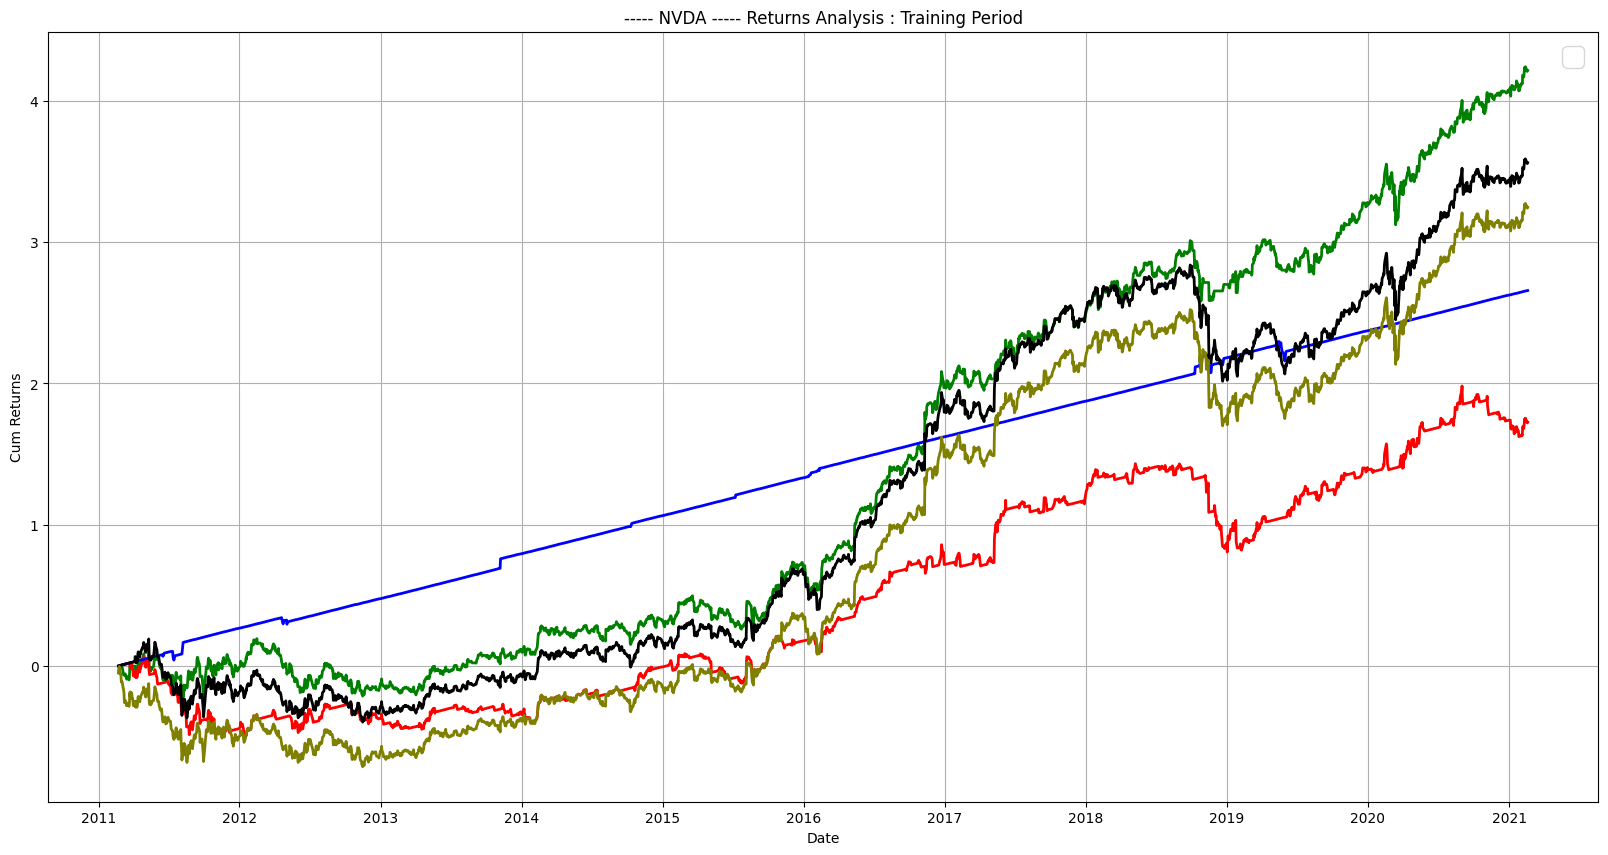

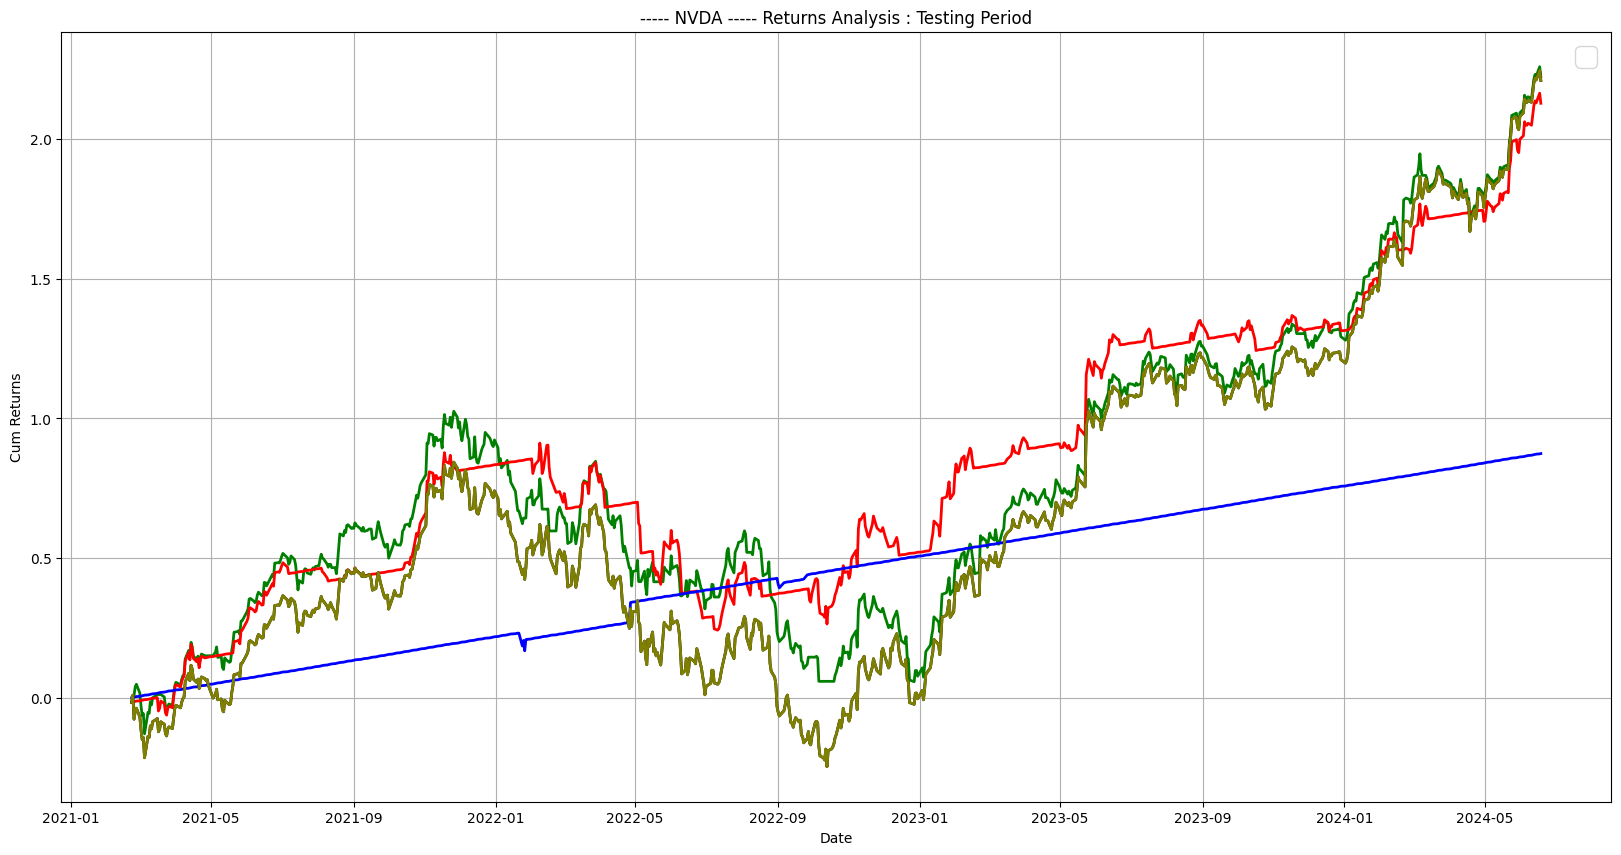

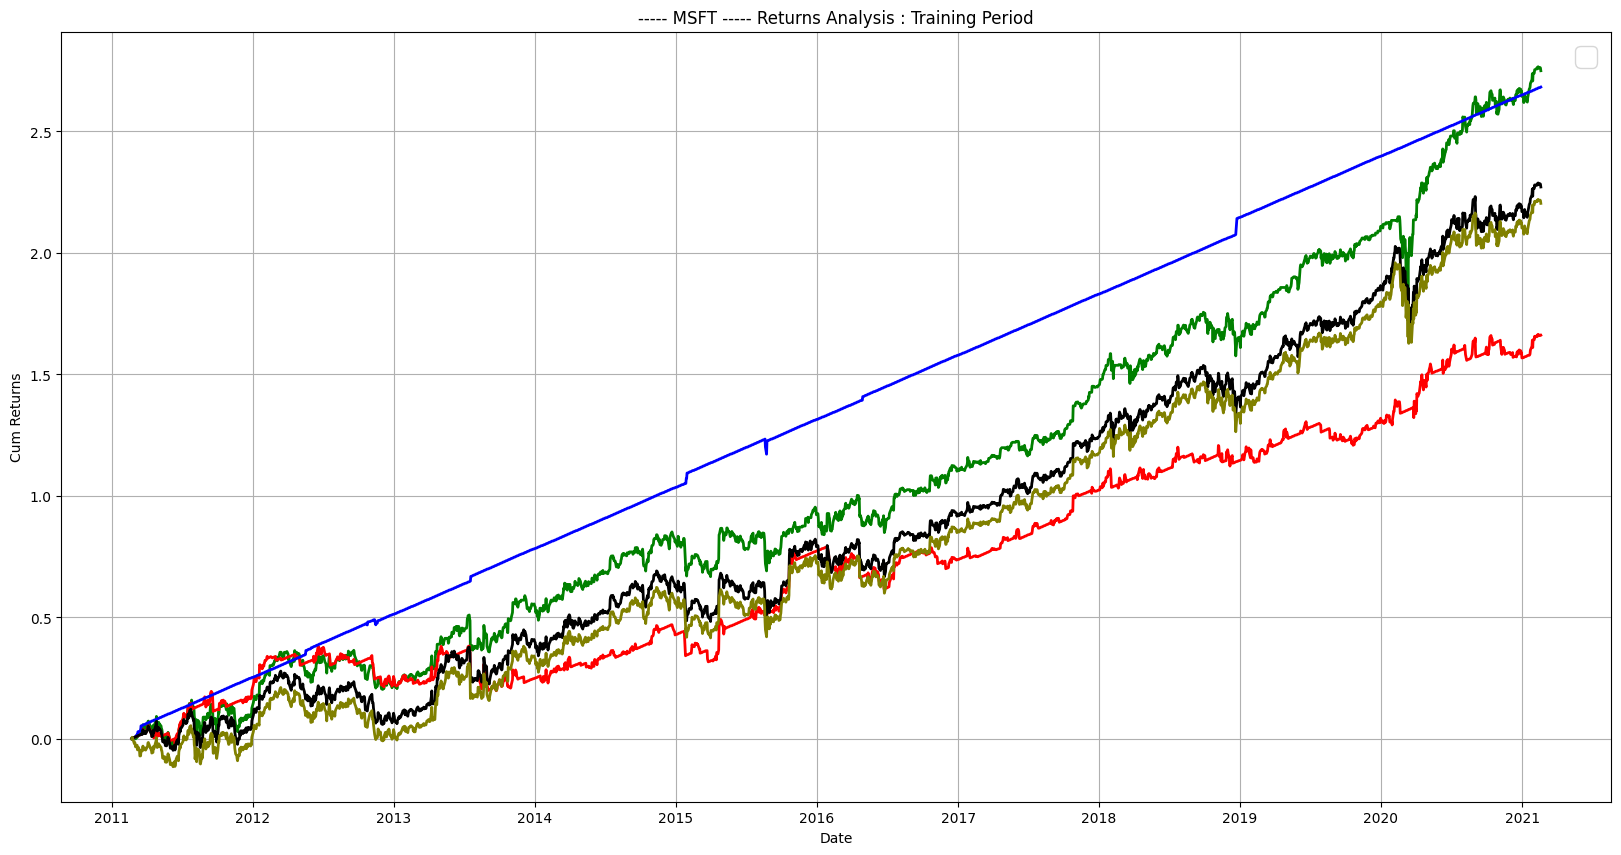

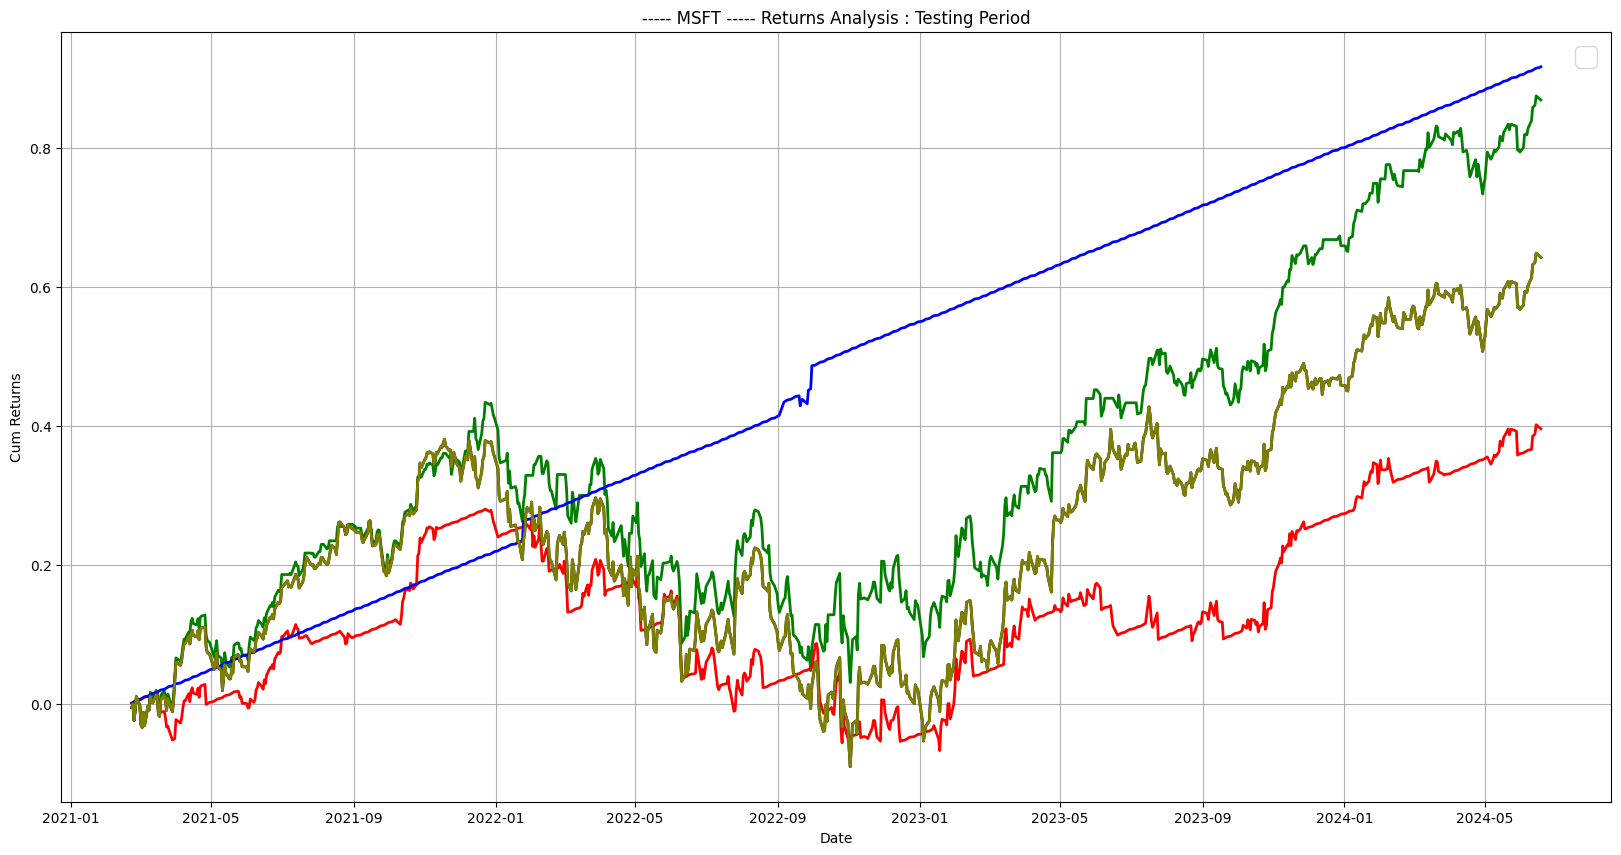

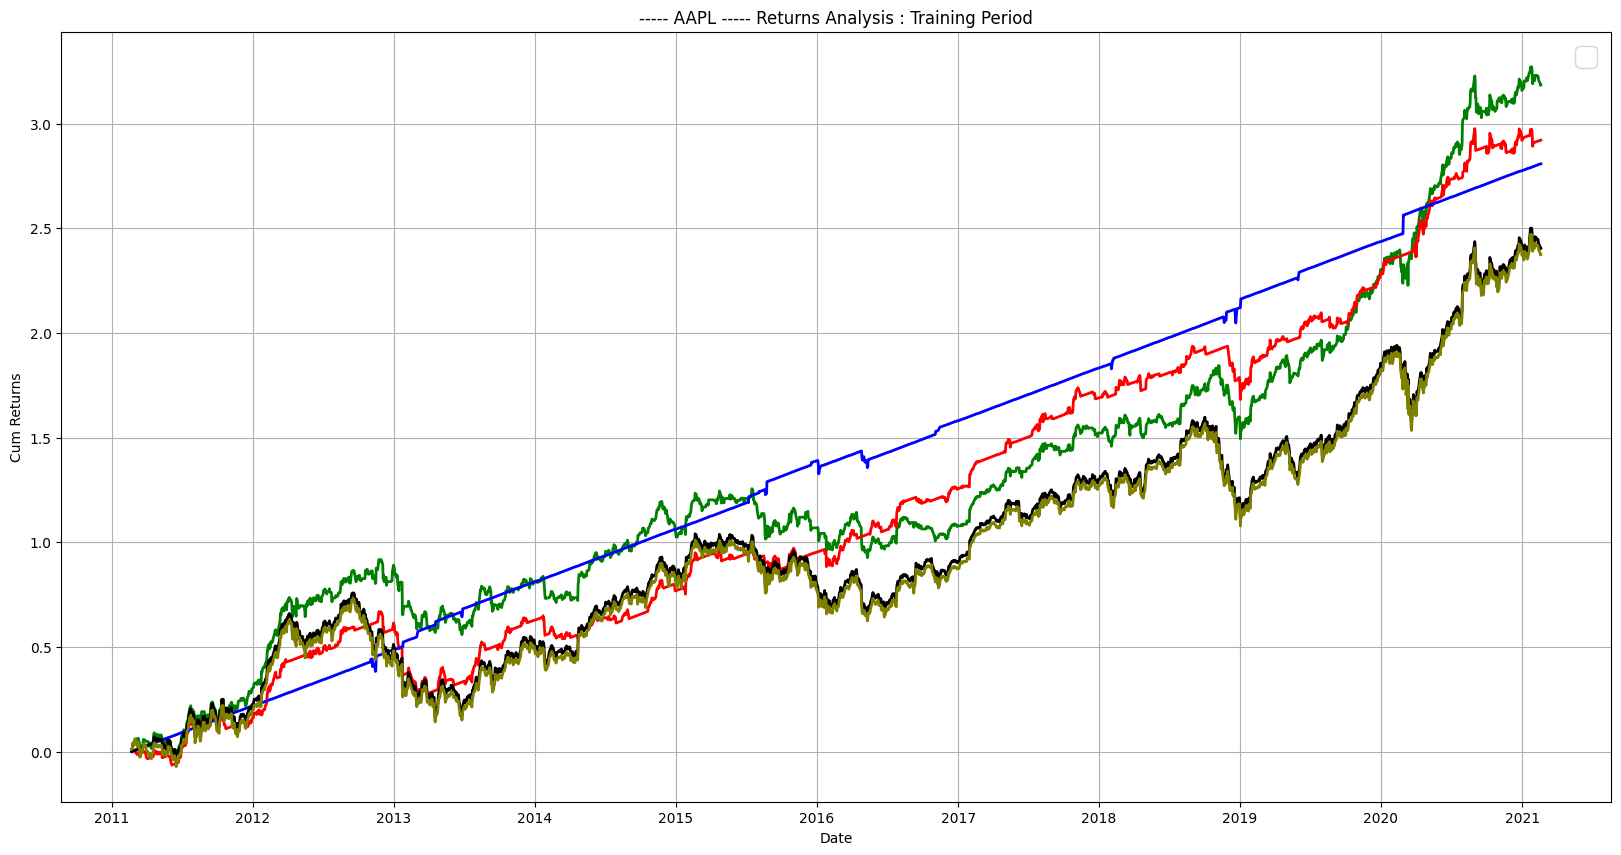

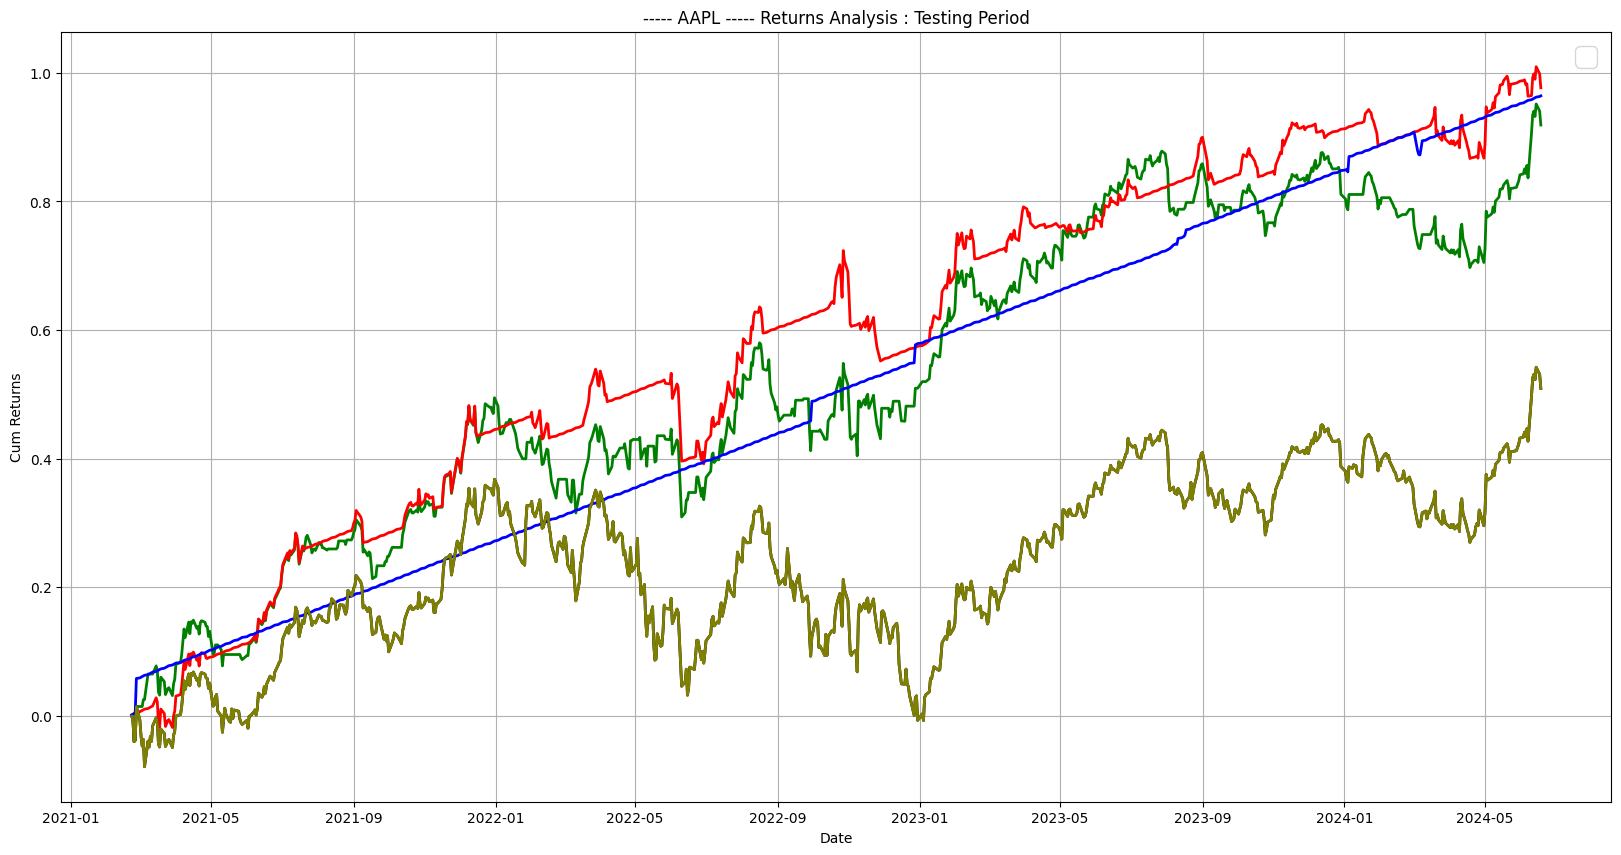

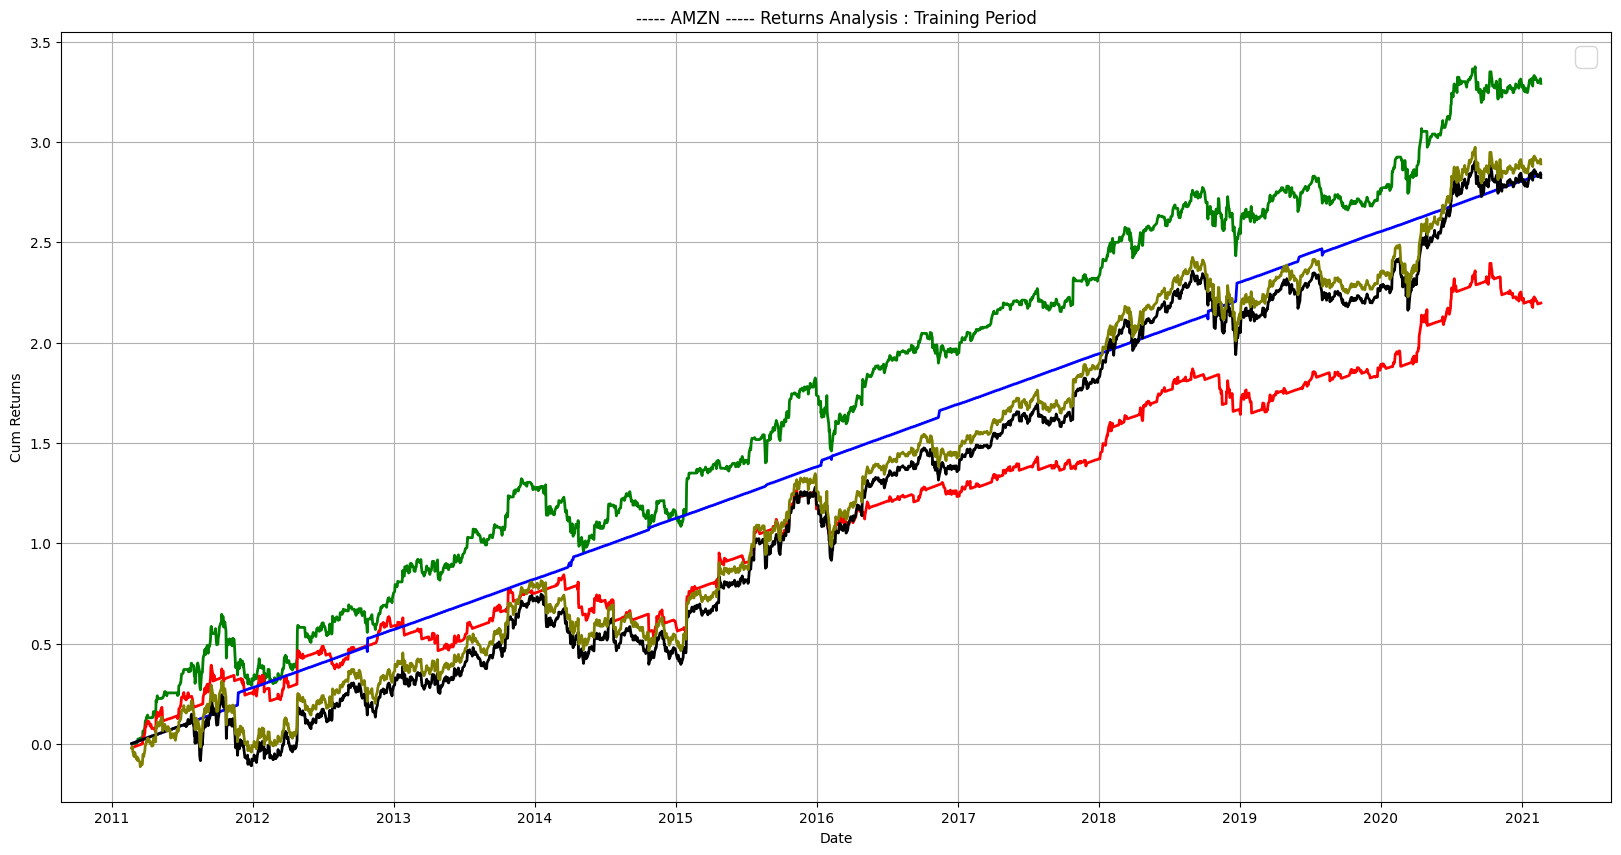

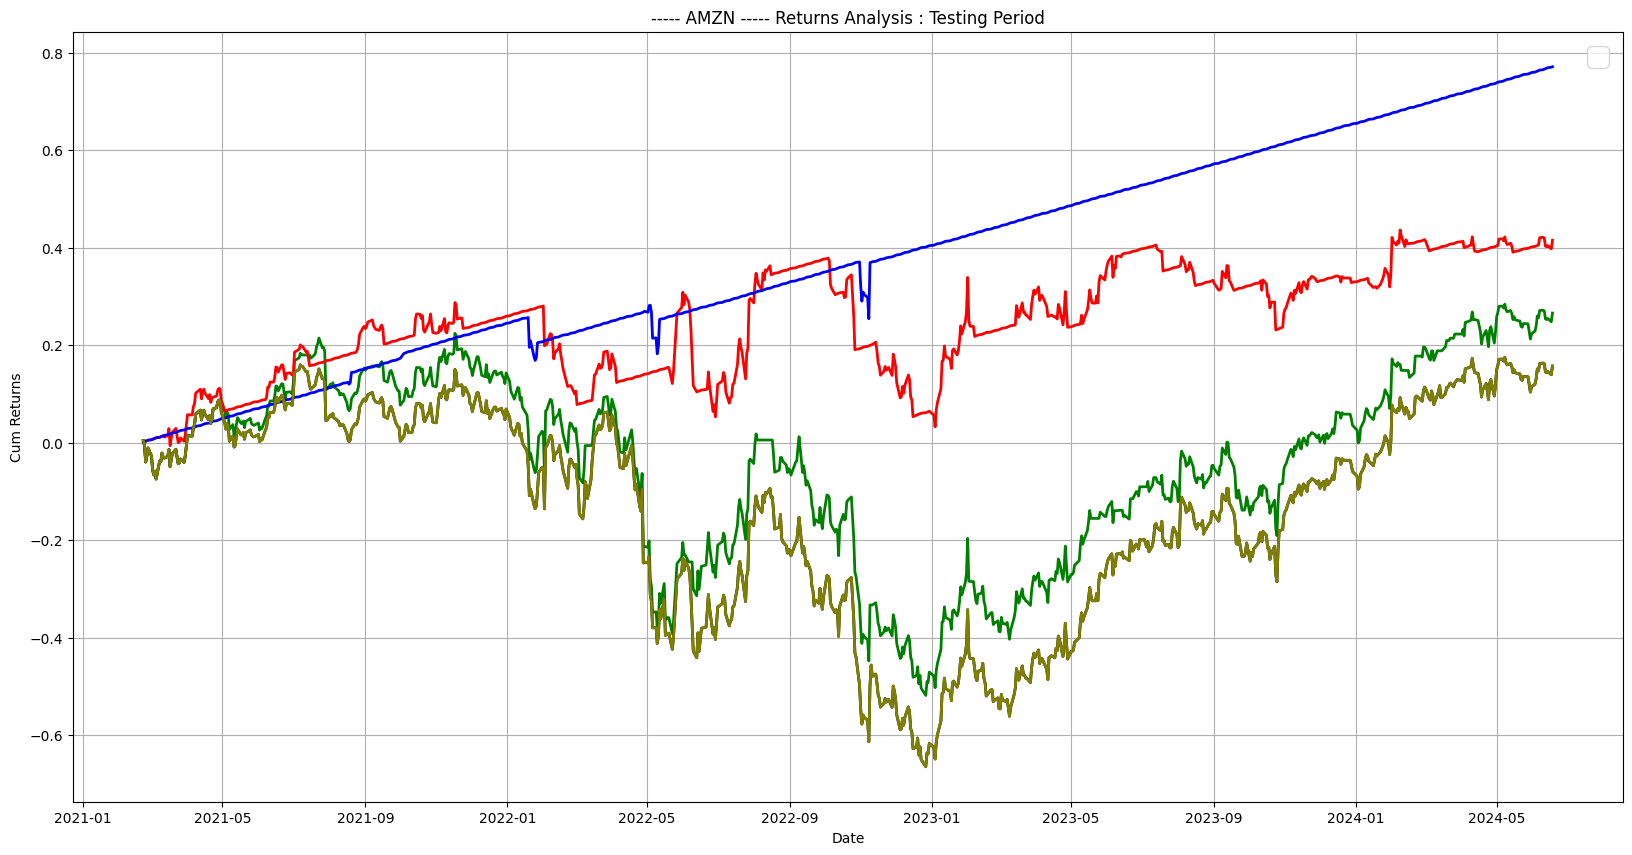

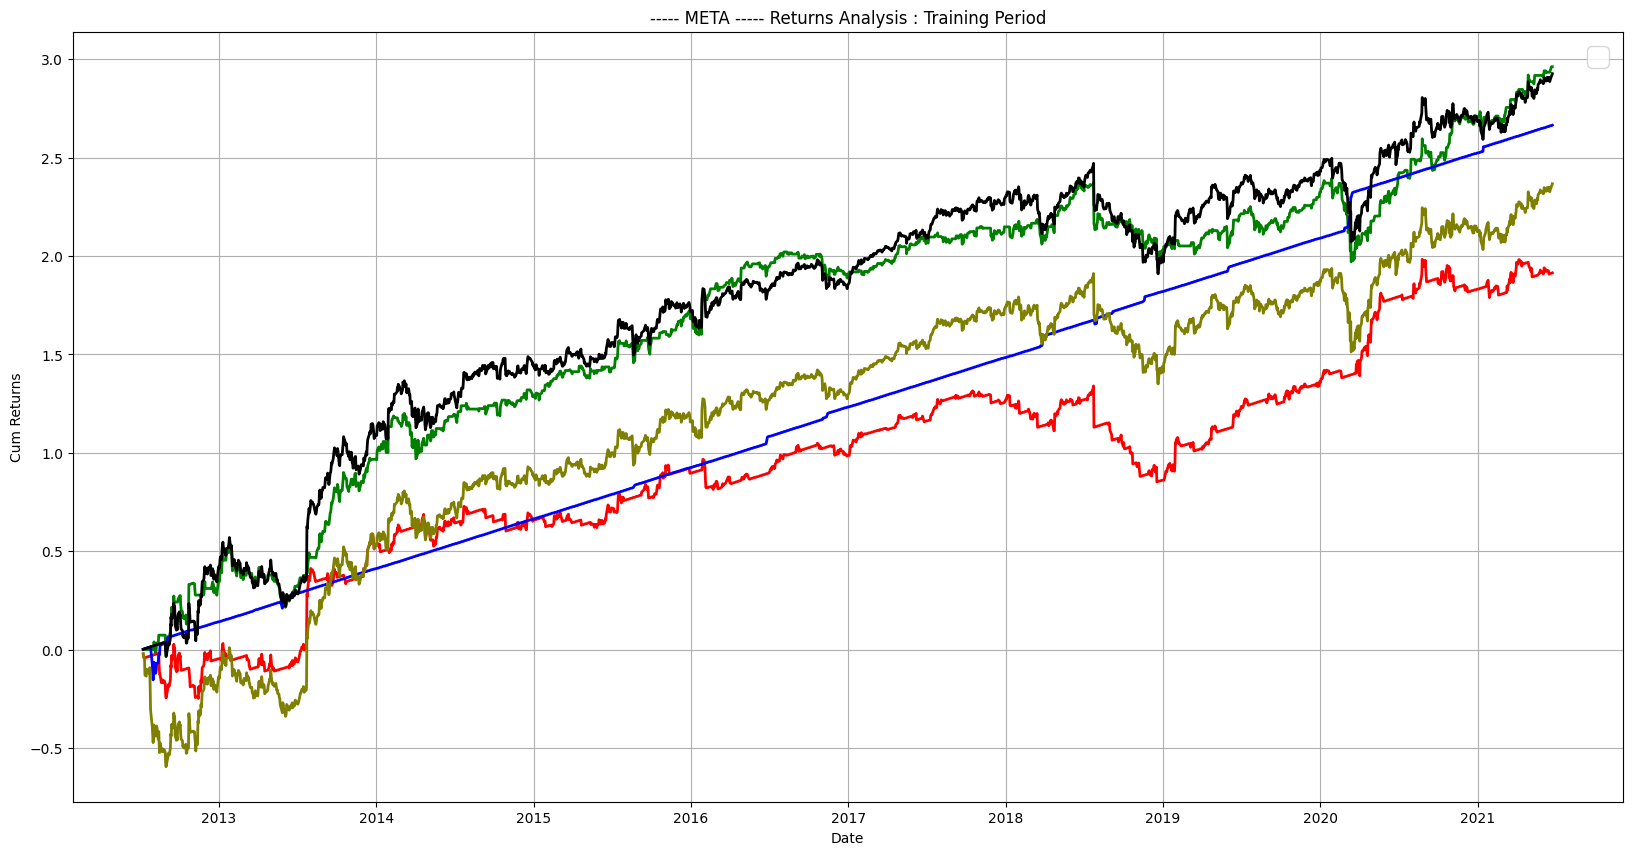

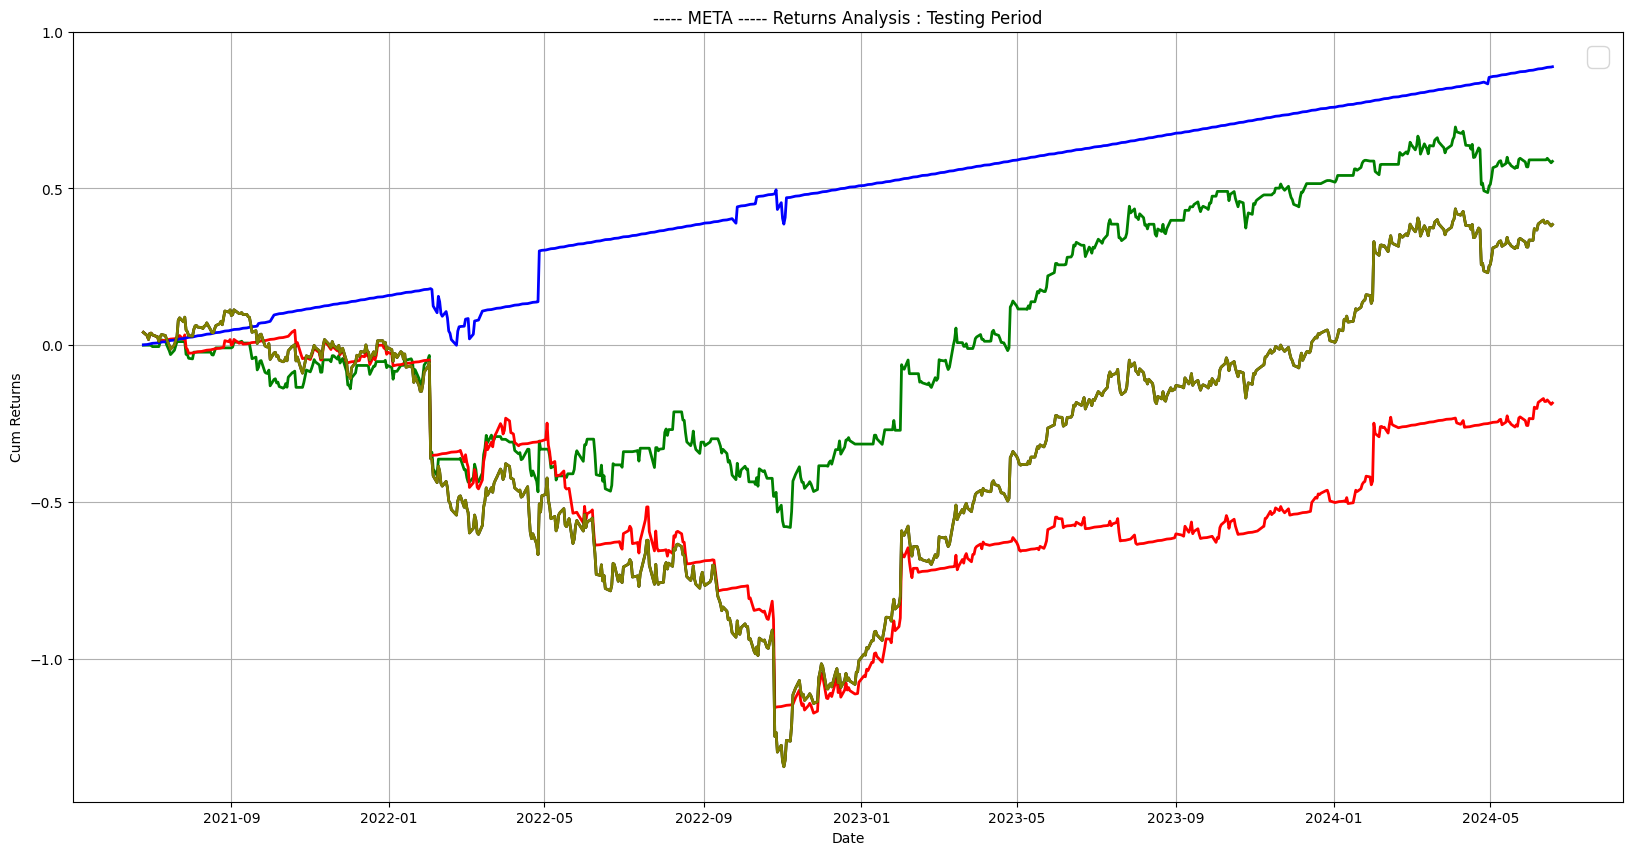

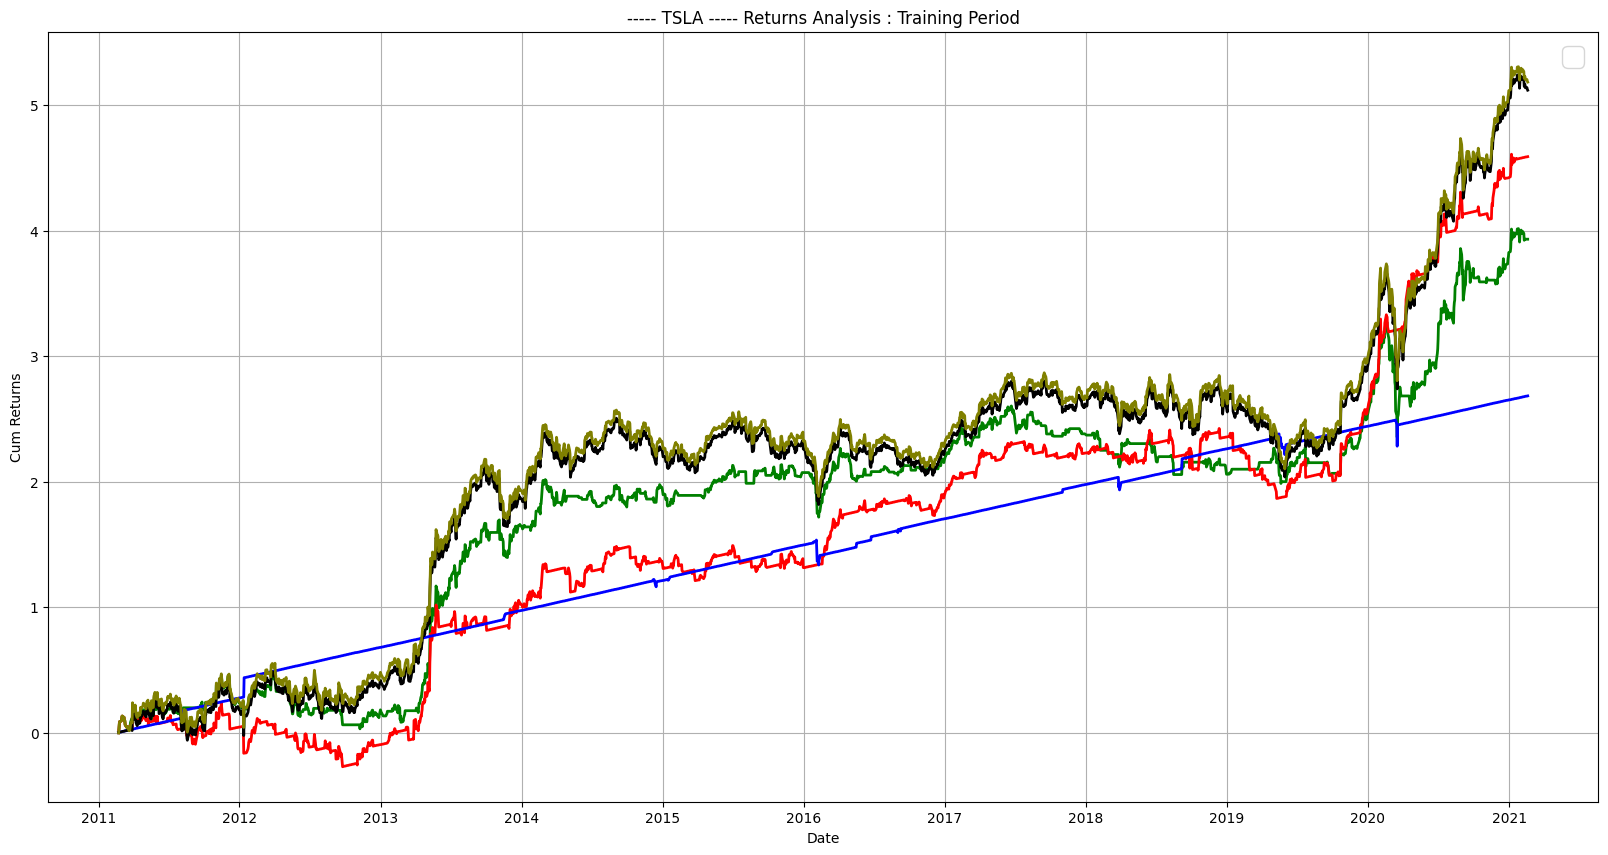

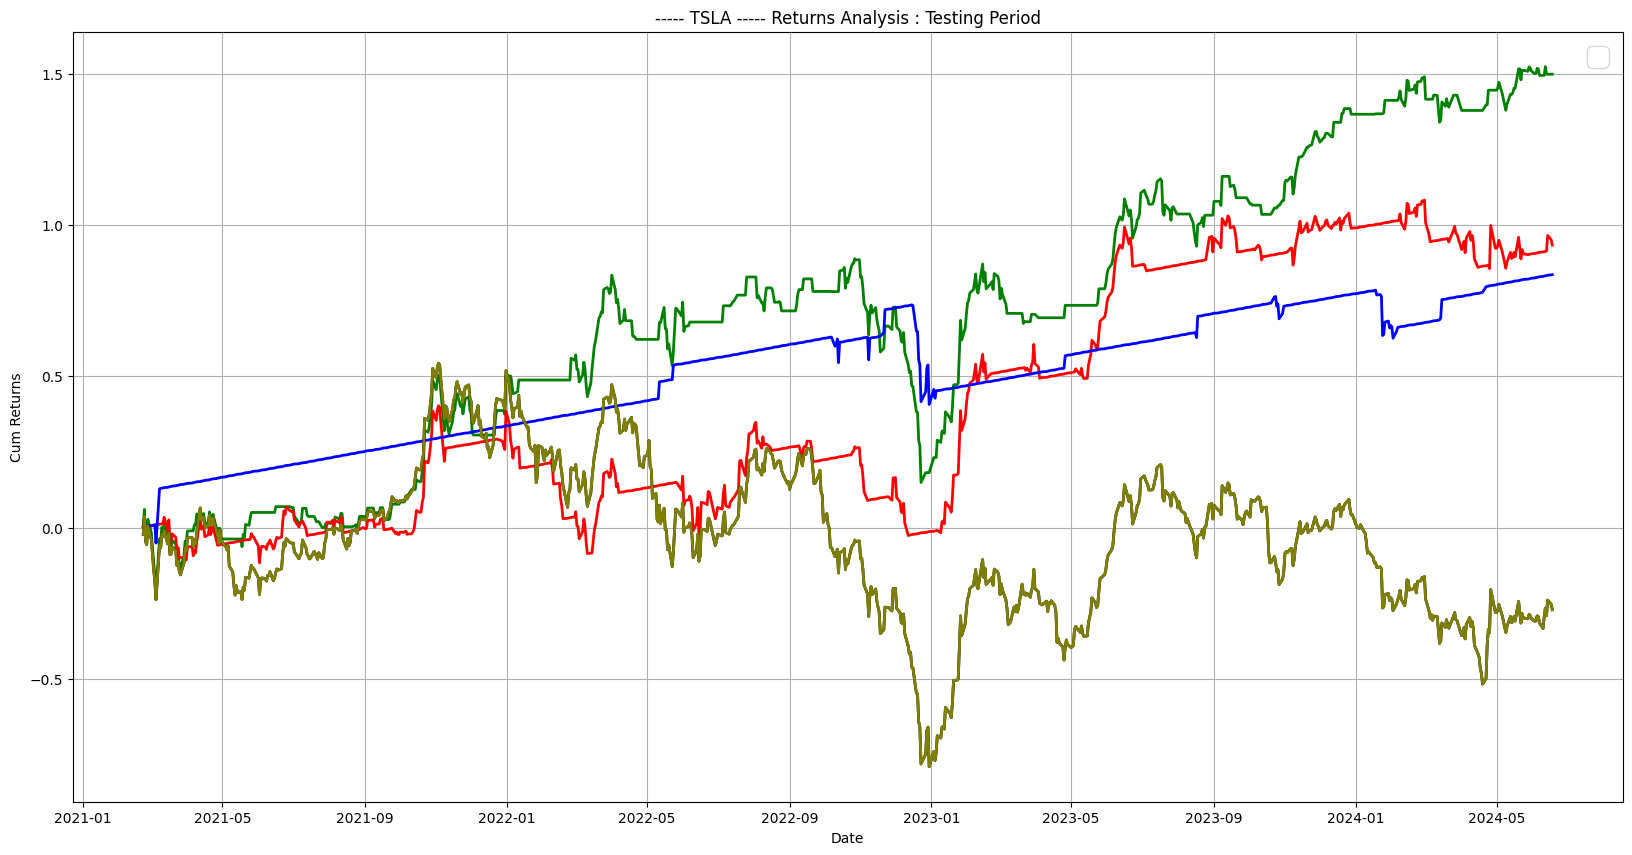

In [26]:
for tick in df['Ticker']:
    workflow(tick) 